<div align="center">

# **Restaurant's Recommendation System - Yelp**

Martina Ibarra - Elena Salomon - Florencia Nebot

MIT-gtl-uruguay-2026

---
</div>


##**1. Context**

The paradox of choice:  "too many options don't liberate users - they freeze them".

Think about ordering coffee these days. Gone are the times when you simply asked for "white" or "black". Now we're faced with selecting the bean origin, roast level, milk type, temperature, size, and whether we'd like any additional flavours. While variety is wonderful, too many choices can lead to anxiety, indecision, and often, complete avoidance of making a choice. [Choice Paralysis: When Too Many Options Kill Your App's Success - Glance](https://https://thisisglance.com/blog/choice-paralysis-when-too-many-options-kill-your-apps-success)




The surge of digital platforms has generated an information overload where reviews from strangers could be useful to make a decision or generate a change of idea.

In this scenario, personal social circles emerge as a fundamental structure that replicates natural human behavior: our consumption decisions are deeply linked to our inner circle of trust or to the opinion of others.

By mapping the experiences and discoveries within a network of friends, the system moves beyond being a simple data search engine to become a tool driven by social influence. Based on the principle of shared preferences, where people who are connected tend to enjoy similar places and standards, a friend’s discovery of a new restaurant becomes the most reliable indicator of interest for others in that group.

##**2. Objective**

To build a personalized recommendation system that transforms Yelp’s massive dataset of millions of records into meaningful suggestions.

To achieve this recommendation system, we will test five models:

1. Average restaurant ratings (Non-Personalized)

2. Collaborative Filtering (K-Nearest Neighbors)

3. Collaborative Filtering (Matrix Factorization)

4. Collaborative Filtering with Friend’s  preferences (Social Graphs)

5. Collaborative Filtering with sentimental analysis


In [ ]:
!pip uninstall numpy -y

Found existing installation: numpy 1.26.0
Uninstalling numpy-1.26.0:
  Successfully uninstalled numpy-1.26.0


In [ ]:
!pip install numpy==1.26.0

  Using cached numpy-1.26.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
Using cached numpy-1.26.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
music21 9.9.1 requires numpy>=1.26.4, but you have numpy 1.26.0 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.0 which is incom

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install surprise

In [ ]:
#Libreries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from surprise.prediction_algorithms.matrix_factorization import SVD
from collections import defaultdict
from surprise.model_selection import KFold
import warnings
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.model_selection import GridSearchCV
from surprise.model_selection import train_test_split
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.model_selection import KFold
from surprise import CoClustering
warnings.filterwarnings('ignore')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ruta_drive = '/content/drive/My Drive/df_yelp_final_4.csv'


df = pd.read_csv (ruta_drive)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1842035 entries, 0 to 1842034
Data columns (total 40 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   review_id                   int64  
 1   business_id                 int64  
 2   user_id                     int64  
 3   city                        object 
 4   rating_user                 int64  
 5   review_text                 object 
 6   review_date                 object 
 7   review_impact_score         int64  
 8   index_impact_review         float64
 9   review_quality              object 
 10  business_name               object 
 11  latitude                    float64
 12  longitude                   float64
 13  user_name                   object 
 14  id_friends                  object 
 15  main_cuisine                object 
 16  influence_user_index        float64
 17  user_type                   object 
 18  ByAppointmentOnly           int64  
 19  BusinessAcceptsCredit

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
review_id,1842035.0,921017.000000,531749.845891,0.000000,460508.500000,921017.000000,1.381526e+06,1.842034e+06
business_id,1842035.0,17475.989906,10202.833450,0.000000,8537.000000,17549.000000,2.641700e+04,3.498600e+04
user_id,1842035.0,315928.232240,263140.144373,0.000000,105657.000000,230788.000000,4.701555e+05,1.087093e+06
rating_user,1842035.0,3.933038,1.355117,1.000000,3.000000,4.000000,5.000000e+00,5.000000e+00
review_impact_score,1842035.0,2.750401,9.415657,-4.000000,0.000000,0.000000,3.000000e+00,1.134000e+03
index_impact_review,1842035.0,0.242540,0.830305,-0.352734,0.000000,0.000000,2.645503e-01,1.000000e+02
latitude,1842035.0,35.530584,5.366648,27.564457,29.954861,36.185558,3.991852e+01,5.367920e+01
longitude,1842035.0,-89.625120,14.270528,-120.083748,-90.242168,-86.272210,-8.232545e+01,-7.468025e+01
influence_user_index,1842035.0,0.117063,1.188659,0.000000,0.000752,0.003507,2.705465e-02,1.000000e+02
ByAppointmentOnly,1842035.0,0.010358,0.101244,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00


**Observations:**

- The average user satisfaction is positive. Half of the ratings were 4 or 5 stars. The average ratings is 3.93. This means that users tend to leave positive reviews.

- Half of the reviews don't generate interactions, the median ofreview_impact_score and index_impact_review is 0.

- Social circle (count_friends): on average, users have 35 friends but the standar deviation is high: 199. 25% of users don't have friends on the platform, while the user with more friends have over 5200.

##**Exploration data analysis**

In [ ]:
# Check the number of rows and columns
df.shape

(1842035, 40)

Due to the large volume of reviews, executing all proposed models on the full dataset is computationally prohibitive.
We have narrowed our scope to Philadelphia, the city with the highest density of restaurant offerings and users who provided at least 5 reviews

In [ ]:
df_philadelphia = df[df['city'] == 'Philadelphia']

df_ph = df_philadelphia.groupby('user_id').filter(lambda x: len(x) >= 5)

print(f"Unique users in Philadelphia subset: {df_ph['user_id'].nunique()}")
df_ph.head()

Unique users in Philadelphia subset: 8714


,review_id,business_id,user_id,city,rating_user,review_text,review_date,review_impact_score,index_impact_review,review_quality,...,DogsAllowed,Alcohol,GoodForKids,RestaurantsTableService,RestaurantsGoodForGroups,DriveThru,NoiseLevel,Smoking,BestNight_Weekend,count_friends
4,4,181,51695,Philadelphia,5,My boyfriend and I tried this deli for the fir...,2018-08-23 21:39:38,0,0.000000,Low Impact,...,0,0,1,0,1,0,u'average',0,0,15
7,7,1730,45740,Philadelphia,5,I've only had the cannolis here but they are a...,2018-03-23 14:35:33,4,0.352734,Useful,...,0,0,0,0,0,0,NaN,0,0,83
32,32,237,329,Philadelphia,4,A wee bit pricey for the portions they serve. ...,2017-07-08 21:23:54,2,0.176367,Low Impact,...,0,0,1,0,0,0,u'average',0,0,1436
35,35,1801,37713,Philadelphia,5,Went here with a friend after having an incred...,2017-06-06 21:42:37,0,0.000000,Low Impact,...,0,1,0,1,0,0,u'average',0,0,10
52,52,1293,107903,Philadelphia,4,Beautiful clean shop with knock your socks off...,2017-02-09 15:35:11,0,0.000000,Low Impact,...,0,0,1,0,1,0,u'average',0,0,4


In [ ]:
df_ph.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111831 entries, 4 to 1842027
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   review_id                   111831 non-null  int64  
 1   business_id                 111831 non-null  int64  
 2   user_id                     111831 non-null  int64  
 3   city                        111831 non-null  object 
 4   rating_user                 111831 non-null  int64  
 5   review_text                 111831 non-null  object 
 6   review_date                 111831 non-null  object 
 7   review_impact_score         111831 non-null  int64  
 8   index_impact_review         111831 non-null  float64
 9   review_quality              111831 non-null  object 
 10  business_name               111831 non-null  object 
 11  latitude                    111831 non-null  float64
 12  longitude                   111831 non-null  float64
 13  user_name         

In [ ]:
df_ph.shape

(111831, 40)

In [ ]:
df_ph.describe().T

,count,mean,std,min,25%,50%,75%,max
review_id,111831.0,901419.919047,529532.644462,4.000000,430114.500000,885785.000000,1.353091e+06,1.842027e+06
business_id,111831.0,17058.373090,10210.955903,0.000000,7898.000000,16766.000000,2.572200e+04,3.498500e+04
user_id,111831.0,161539.493155,132779.329807,1.000000,59576.000000,117682.000000,2.236050e+05,9.854830e+05
rating_user,111831.0,4.017911,1.149689,1.000000,3.000000,4.000000,5.000000e+00,5.000000e+00
review_impact_score,111831.0,4.356377,11.431239,0.000000,0.000000,2.000000,4.000000e+00,4.670000e+02
index_impact_review,111831.0,0.384160,1.008046,0.000000,0.000000,0.176367,3.527337e-01,4.118166e+01
latitude,111831.0,39.962992,0.035815,39.865466,39.948100,39.951760,3.996395e+01,4.013325e+01
longitude,111831.0,-75.158615,0.037025,-75.363647,-75.170899,-75.161698,-7.514951e+01,-7.495799e+01
influence_user_index,111831.0,0.201576,1.608330,0.000000,0.003507,0.020541,8.041243e-02,1.000000e+02
ByAppointmentOnly,111831.0,0.016462,0.127246,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00


The dataset with Philadelphia restaurants and users that rated at least 5 restaurants contains 111.831 reviews and 40 features. This features are characteristics of the restaurant, the review or the user.

###1.Missing values

Only two features have missing values. Restaurant Price Range we can impute the median by main_cuisine, with noiseLevel (12% nulls) we are not going to treat it since we don't find it relevant to the analysis.

In [ ]:
pd.DataFrame({
    "Count" : df_ph.isnull().sum()[df_ph.isnull().sum() > 0],

    "Percentage" : (df_ph.isnull().sum()[df_ph.isnull().sum() > 0] / df_ph.shape[0]) * 100})

,Count,Percentage
RestaurantsPriceRange2,7210,6.447228
NoiseLevel,13496,12.068210



We were going to compute nulls with the median of each main_cuisine, but all cuisines have the same median in the restaurant prince range, so we compute 2 to all nulls

In [ ]:
df_ph.groupby('main_cuisine').RestaurantsPriceRange2.describe()


,count,mean,std,min,25%,50%,75%,max
main_cuisine,,,,,,,,
American & Fast Food,10025.0,2.023541,0.638018,1.0,2.0,2.0,2.0,4.0
Asian,22229.0,1.940618,0.496506,1.0,2.0,2.0,2.0,4.0
Breakfast & Deli,3530.0,1.686119,0.562908,1.0,1.0,2.0,2.0,3.0
Cafe & Desserts,13456.0,1.726219,0.626516,1.0,1.0,2.0,2.0,3.0
European,6596.0,2.169800,0.564535,1.0,2.0,2.0,2.0,4.0
Healthy & Specialized,3886.0,1.824756,0.499075,1.0,2.0,2.0,2.0,3.0
International & Others,3982.0,1.889503,0.509488,1.0,2.0,2.0,2.0,4.0
Latin & Caribbean,7697.0,1.816032,0.456459,1.0,2.0,2.0,2.0,3.0
Other,1083.0,1.903047,0.489086,1.0,2.0,2.0,2.0,3.0


In [ ]:
price_mode = df_ph['RestaurantsPriceRange2'].median()

df_ph['RestaurantsPriceRange2'] = df_ph['RestaurantsPriceRange2'].fillna(price_mode)

print(f"The mode used for imputation was: {price_mode}")
print(f"Remaining nulls in Price Range: {df_ph['RestaurantsPriceRange2'].isnull().sum()}")

The mode used for imputation was: 2.0
Remaining nulls in Price Range: 0


In [ ]:
#Drop noiseLevel column
df_ph.drop(columns=['NoiseLevel'], inplace=True)

###2.Duplicated

There are no duplicated rows in our dataset.

In [ ]:
pd.DataFrame({
    "Count" : df_ph.duplicated().sum()[df_ph.duplicated().sum() > 0],

    "Percentage" : (df_ph.duplicated().sum()[df_ph.duplicated().sum() > 0] / df_ph.shape[0]) * 100})

,Count,Percentage


### 3.Unique users, restaurants and reviews

In [ ]:
#Unique users
df_ph.user_id.nunique()

8714

In [ ]:
#Unique business
df_ph.business_id.nunique()

3372

In [ ]:
# Find the sum of total ratings count by each user restaurant pair
df_ph.groupby(['user_id', 'business_id']).count()['rating_user'].sum()

111831

The dataset contains 8714 unique users and 3372 unique restaurants. Theoretically, there is a total of 29.383.608 possible ratings. However, with only 111.831 actual ratings present, it is clear that not every user has rated every restaurant. This sparsity presents an opportunity to build a recommendation system to suggest new restaurants to users based on their preferences.

###**4.Visualizations**

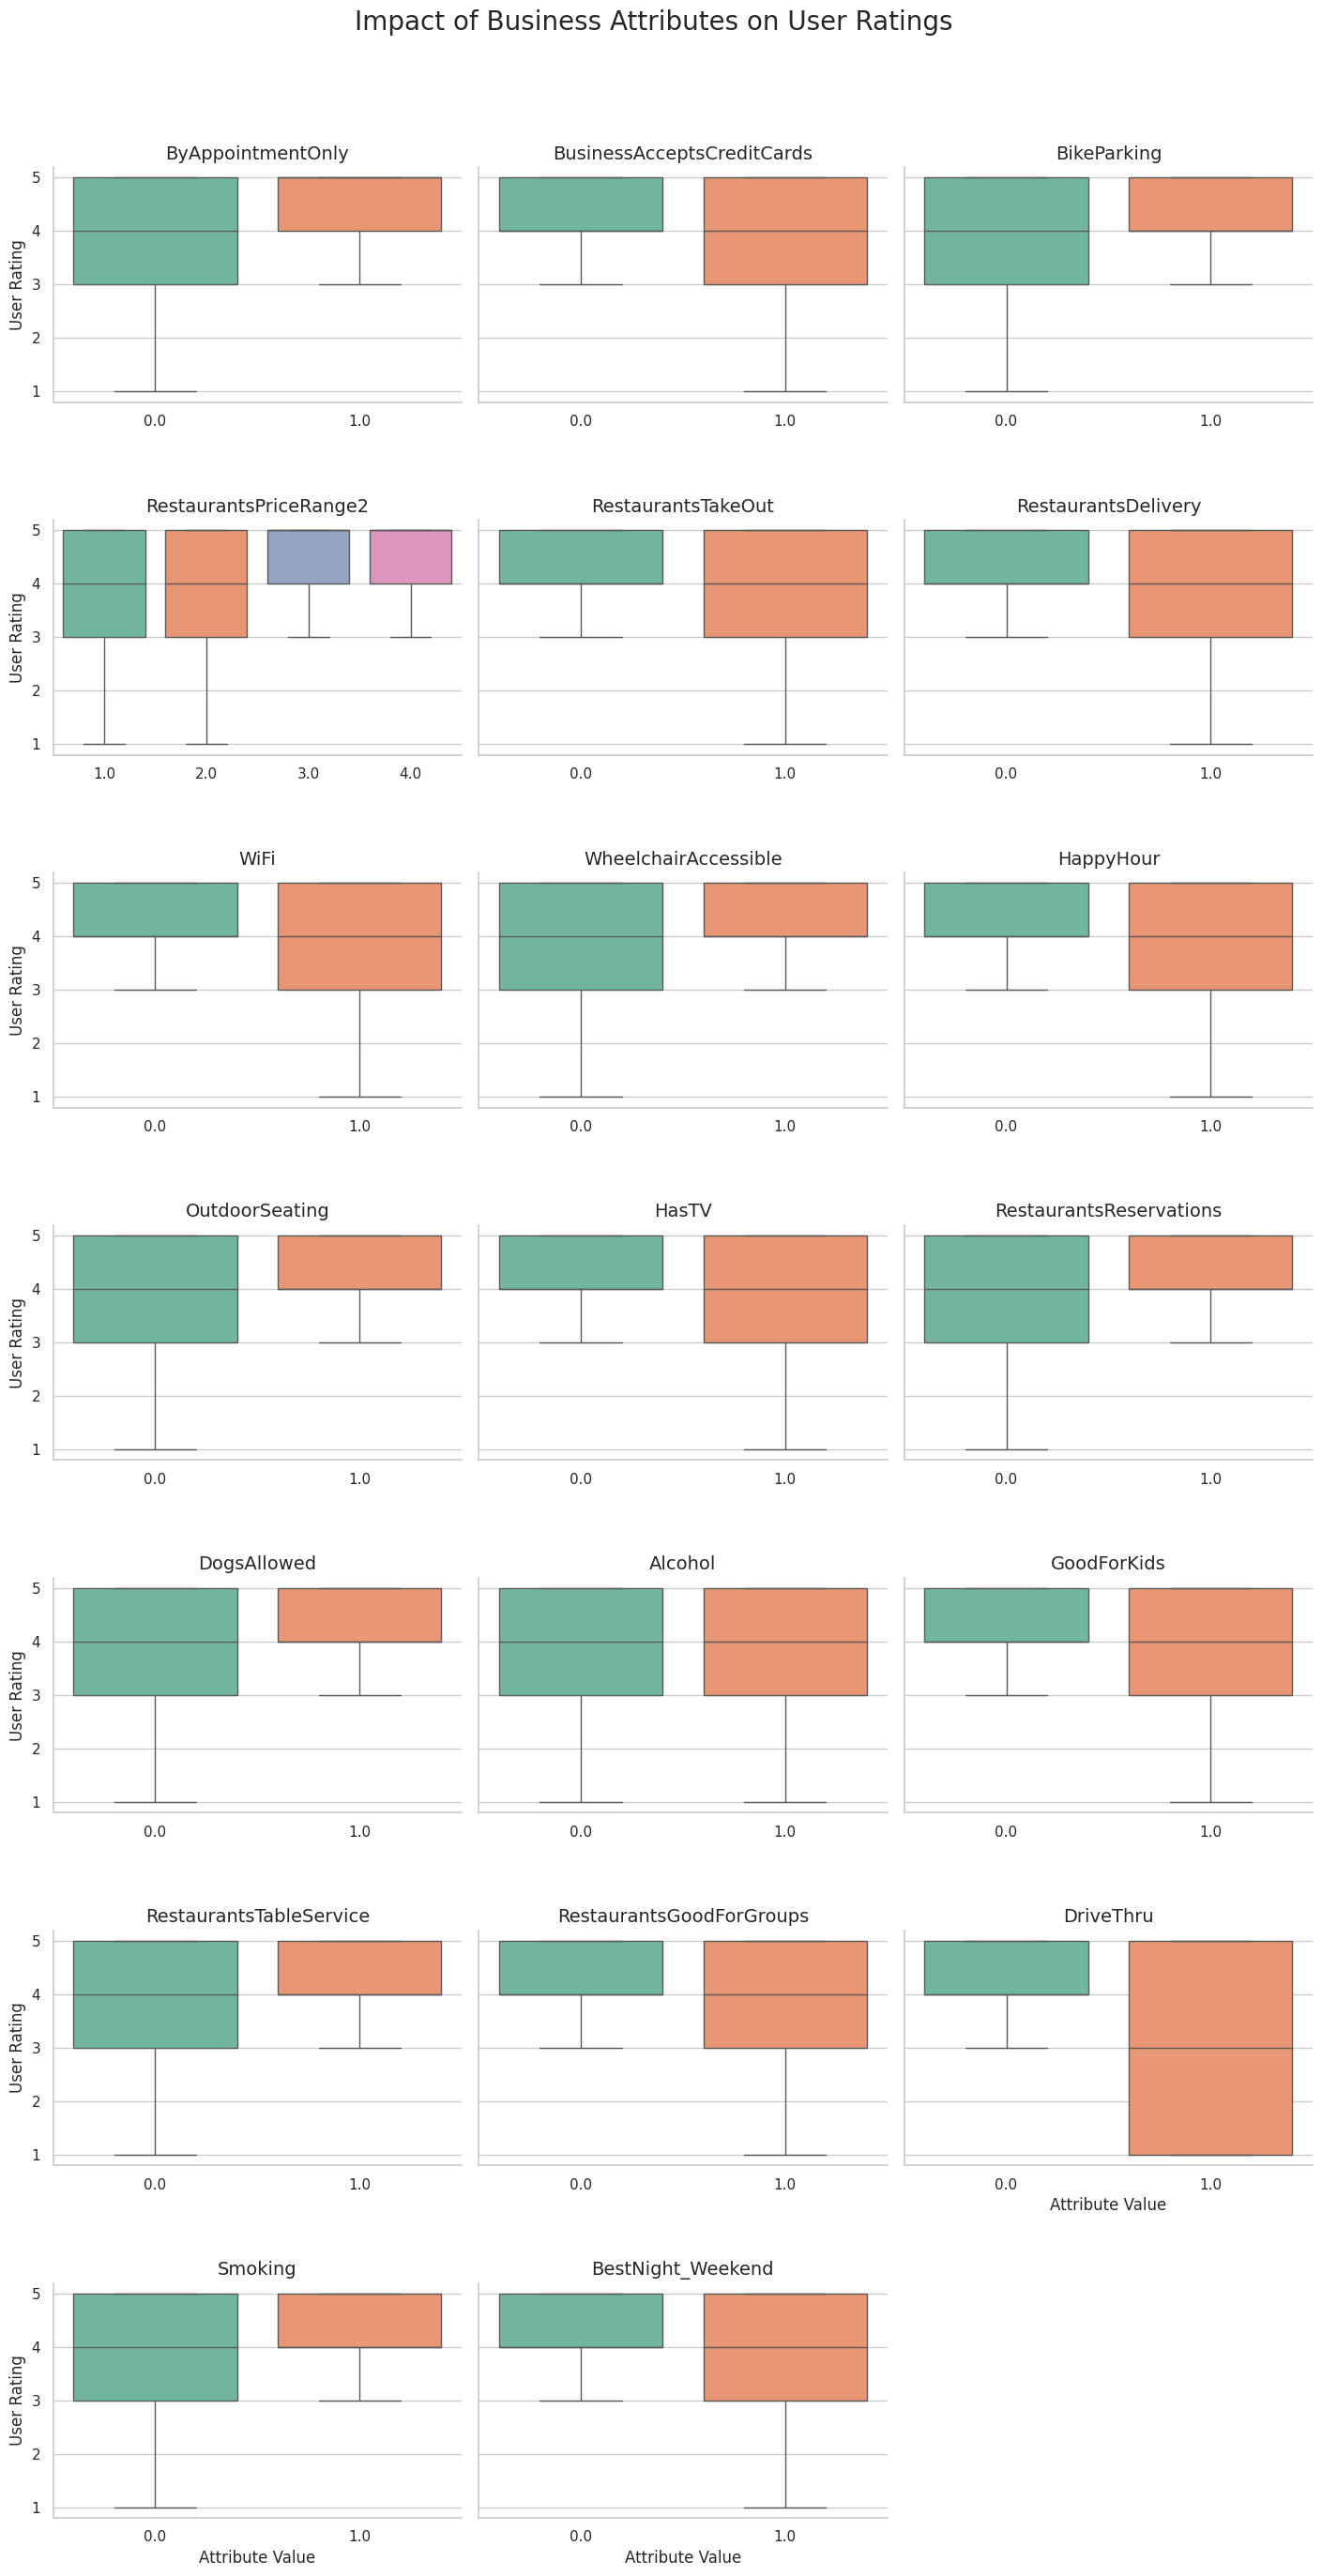

In [ ]:
features_to_plot = df_ph.loc[:, 'ByAppointmentOnly':'BestNight_Weekend'].columns.tolist()

df_melted = df_ph.melt(id_vars=['rating_user'], value_vars=features_to_plot)

sns.set(style="whitegrid")

g = sns.FacetGrid(df_melted, col="variable", col_wrap=3,
                  sharex=False, sharey=True, height=4, aspect=1.2)

g.map(sns.boxplot, "value", "rating_user", palette='Set2', showfliers=False)

g.set_titles("{col_name}", size=14)
g.set_axis_labels("Attribute Value", "User Rating")
plt.subplots_adjust(top=0.92, hspace=0.5)
g.fig.suptitle('Impact of Business Attributes on User Ratings', fontsize=20)

plt.show()


- Restaurants with a Drive-Thru show a noticeably lower median rating and a wider distribution of low-score outliers. These establishments struggle to meet the quality expectations of the average reviewer.

- PriceRange seems to be a good quality proxy. Ratings are more stable and lean higher in the mid-to-high price tiers ($3.0$ and $4.0$). The lowest tier ($1.0$) exhibits the highest volatility, indicating a less predictable customer experience.

- Credit Cards & Bike Parking: These attributes do not change the median rating, they act as quality floors. Their presence reduces the variance in user ratings by eliminating the lowest scores (1-2 stars) seen in businesses without these attributes.

- The presence of WiFi does not shift the median rating in the Philadelphia market, suggesting it is not a primary factor in overall restaurant satisfaction.

- Table Service & Reservations: These attributes show a "tighter" distribution towards higher ratings. Formal service structures appear to provide a more consistent and professional experience that shields the business from extreme negative ratings.

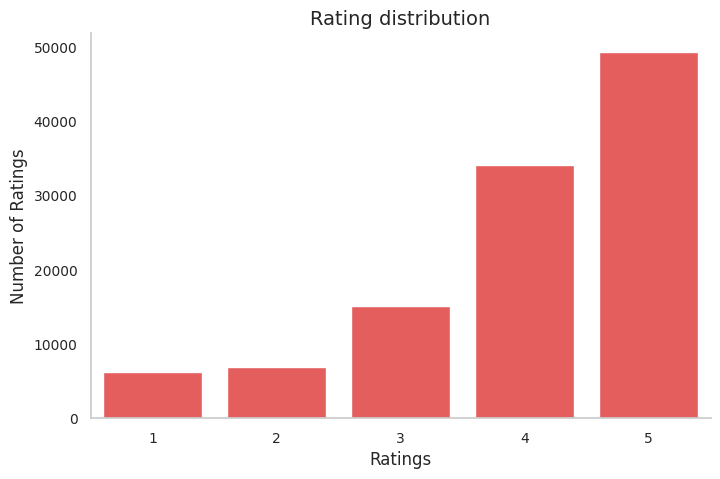

In [ ]:
# User rating distribution

plt.figure(figsize = (8, 5))

ax = sns.countplot(x = "rating_user", data = df_ph, color = '#FA4848')

plt.grid(False)
sns.despine()

plt.tick_params(labelsize = 10)
plt.title("Rating distribution", fontsize = 14)
plt.xlabel("Ratings", fontsize = 12)
plt.ylabel("Number of Ratings", fontsize = 12)

plt.show()


The data seems to be highly skewed toward high ratings. The vast majority of users leave 4 and 5-star reviews, while 1 and 2-star ratings are the least frequent.

Users are more motivated to write reviews for exceptionally good experiences rather than average ones.




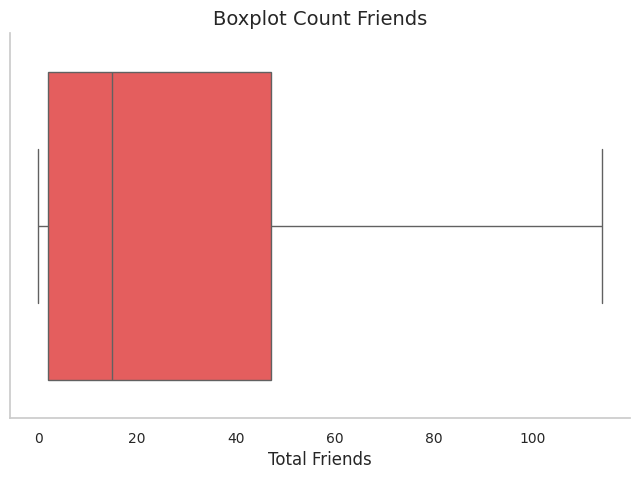

In [ ]:
plt.figure(figsize = (8, 5))

ax = sns.boxplot(x = "count_friends", data = df_ph, color = '#FA4848', showfliers = False)

plt.grid(False)
sns.despine()

plt.tick_params(labelsize = 10)
plt.title("Boxplot Count Friends", fontsize = 14)
plt.xlabel("Total Friends", fontsize = 12)

plt.show()

In [ ]:
#Describe count_friends
df_ph['count_friends'].describe()

,count_friends
count,111831.000000
mean,69.632723
std,296.274723
min,0.000000
25%,2.000000
50%,15.000000
75%,47.000000
max,4932.000000


In [ ]:
top_10_business = df_ph.groupby('business_name')['rating_user'].count().sort_values(ascending=False).head(10)

In [ ]:
df_ph.groupby('business_name')['rating_user'].count().sort_values()

,rating_user
business_name,
Posh Fuel and Food,1
Colney Delicatessen,1
Hong Qi Gong,1
Suzani Palace,1
Sushi Ya,1
...,...
Parc,615
Suraya,644
Zahav,648


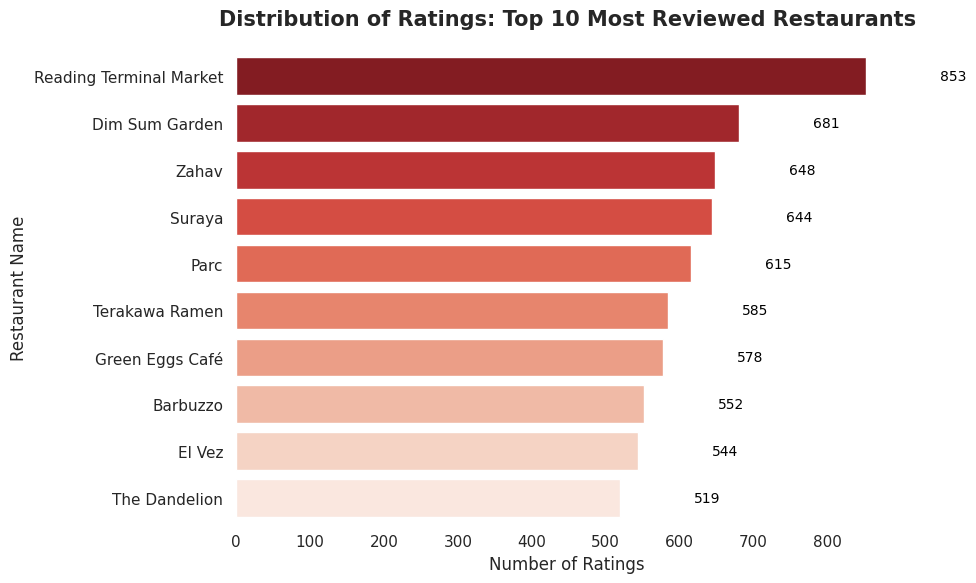

In [ ]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    y=top_10_business.index,
    x=top_10_business.values,
    palette="Reds_r"
)

plt.title('Distribution of Ratings: Top 10 Most Reviewed Restaurants',
          fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Number of Ratings', fontsize=12)
plt.ylabel('Restaurant Name', fontsize=12)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1000:g}K' if x >= 1000 else f'{x:g}'))

for i, v in enumerate(top_10_business.values):
    ax.text(v + 100, i, f'{v:,}', color='black', va='center', fontsize=10)

ax.grid(False)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


- Reading Terminal Market is the leader restaurant in engagement with 853 reviews.

- There is a notable presence of Asian cuisine within the top rankings, led by Dim Sum Garden (681) and Terakawa Ramen (585), indicating a highly active and vocal customer base in this niche.

- Every restaurant in the Top 10 has exceeded the 500 review threshold.

In [ ]:
# FOr each business_name brings the times it appears in the dataset (number of ratings) and the avg. rating
business_counts = df_ph.groupby('business_name').agg(
    count=('business_name', 'count'),
    mean=('rating_user', 'mean')
).sort_values(by='count', ascending=False)

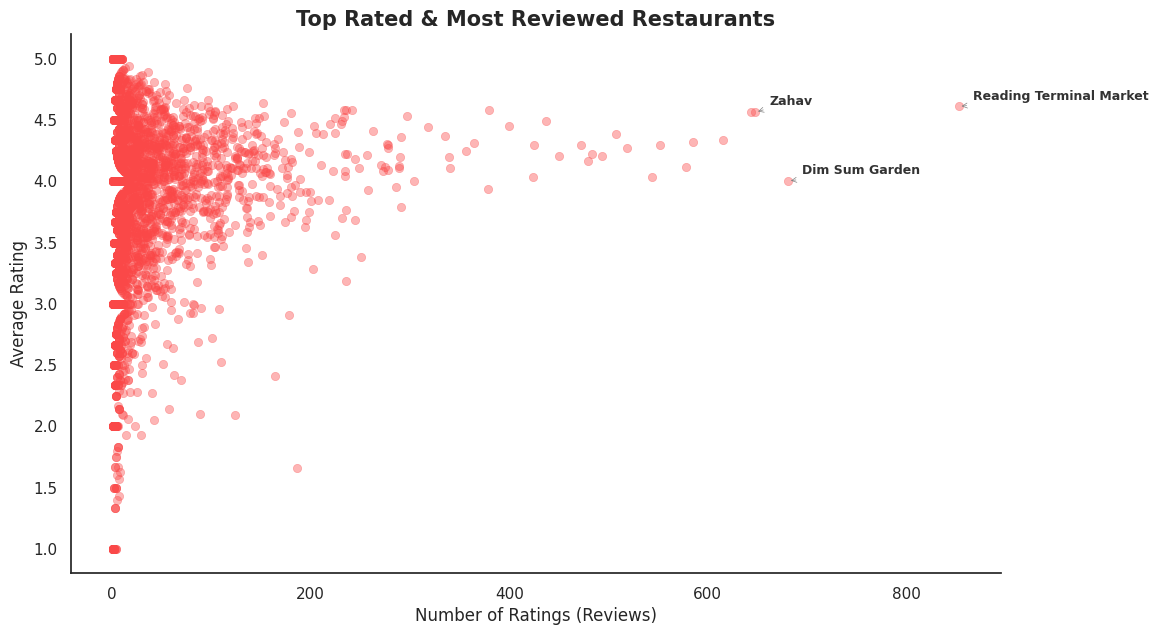

In [ ]:
plt.figure(figsize=(12, 7))

# 1. Graficamos todos los puntos
sns.scatterplot(data=business_counts,
                x='count',
                y='mean',
                color='#FA4848',
                alpha=0.4,
                edgecolor=None)

# 2. Seleccionamos los top 5 por cantidad de reseñas para etiquetar
top_restaurants = business_counts.nlargest(3, 'count')

# 3. Recorremos los elegidos y agregamos el texto
for name, row in top_restaurants.iterrows():
    plt.annotate(
        name,                      # El nombre del restaurante (índice del DF)
        (row['count'], row['mean']), # Coordenadas (x, y)
        xytext=(10, 5),            # Desplazamiento del texto para que no tape el punto
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        color='#333333',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.5) # Flechita opcional
    )

plt.title('Top Rated & Most Reviewed Restaurants', fontsize=15, fontweight='bold')
plt.xlabel('Number of Ratings (Reviews)', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)

plt.grid(False)
sns.despine()

plt.show()

The majority of restaurants receive few reviews and maintain high average ratings, as users tend to provide feedback primarily after positive experiences. However, as restaurants accumulate more reviews, their ratings tend to stabilize at slightly lower values. This trend highlights top-tier establishments that manage to maintain high standards despite a large volume of feedback, such as Reading Terminal Market.

Average rating of 'El Vez' is: 4.03


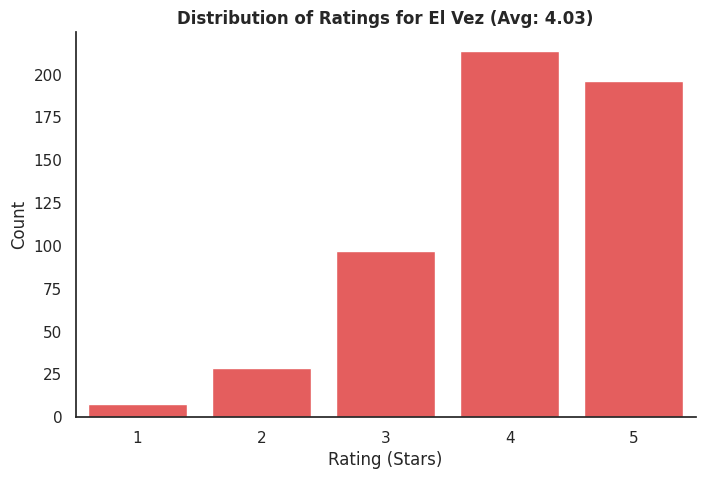

In [ ]:
el_vez = df_ph[df_ph['business_name'] == "El Vez"]

mcd_average = el_vez['rating_user'].mean()

print(f"Average rating of 'El Vez' is: {mcd_average:.2f}")

plt.figure(figsize=(8, 5))
sns.countplot(x='rating_user', data=el_vez, color='#FA4848')

plt.title(f"Distribution of Ratings for El Vez (Avg: {mcd_average:.2f})", fontweight='bold')
plt.xlabel('Rating (Stars)')
plt.ylabel('Count')
ax.grid(False)
sns.despine()
plt.show()

In [ ]:
top_users = df_ph.groupby('user_id').agg(
    count=('user_id', 'count'),
    mean=('rating_user', 'mean')
).sort_values(by='count', ascending=False).head(10)

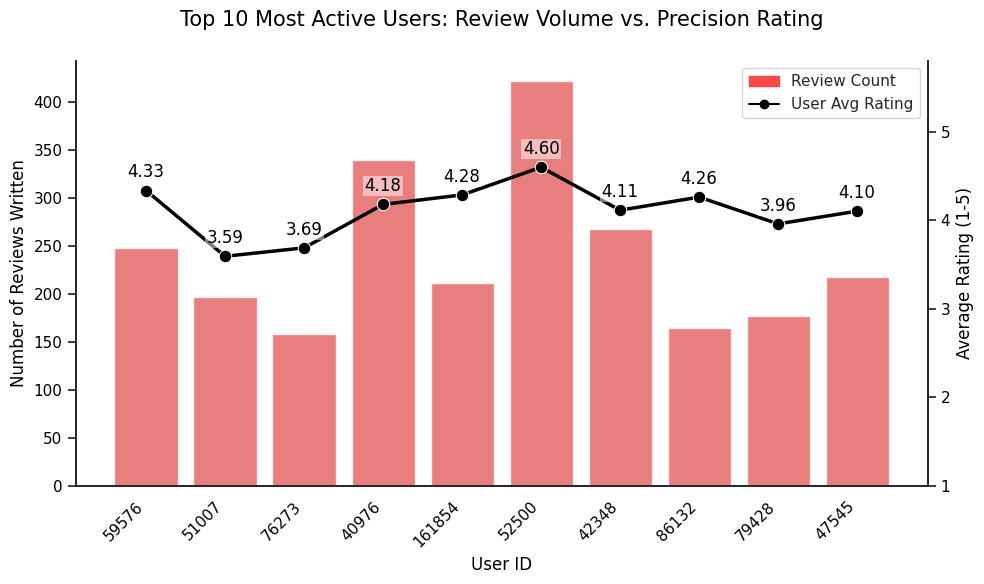

In [ ]:

sns.set_style("white")
fig, ax1 = plt.subplots(figsize=(10, 6))

verde_avg = '#000000'
rojo_barras = '#FA4848'

sns.barplot(x=top_users.index, y=top_users['count'], color=rojo_barras, alpha=0.8, ax=ax1)
ax1.set_xlabel('User ID', fontsize=12, color='black')
ax1.set_ylabel('Number of Reviews Written', fontsize=12, color='black')
ax1.tick_params(axis='both', labelcolor='black')
ax1.set_xticks(range(len(top_users)))
ax1.set_xticklabels(top_users.index, rotation=45, ha='right')

ax2 = ax1.twinx()
sns.lineplot(x=range(len(top_users)), y=top_users['mean'], color=verde_avg,
             marker='o', markersize=9, linewidth=2.5, ax=ax2)

for i, val in enumerate(top_users['mean']):
    ax2.text(i, val + 0.15, f'{val:.2f}',
             color='black', ha='center',
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))
ax2.set_ylabel('Average Rating (1-5)', fontsize=12, color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(1, 5.8)


ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

patch_reviews = mpatches.Patch(color=rojo_barras, label='Review Count')
line_rating = plt.Line2D([0], [0], color=verde_avg, marker='o', label='User Avg Rating')

plt.legend(handles=[patch_reviews, line_rating], loc='upper right', frameon=True)

plt.title('Top 10 Most Active Users: Review Volume vs. Precision Rating',
          fontsize=15, pad=25, color='black')

fig.tight_layout()
plt.show()


This chart illustrates the average rating for the top 10 most active users. We can observe a significant subjective bias: for instance, User 52500 has a very high baseline (4.60), while User 51007 is more critical (3.59). This variance proves that 'stars' are relative. Furthermore, these data support the theory that as users visit more restaurants, they tend to become more discerning and demanding, leading to a natural decrease in their average ratings.

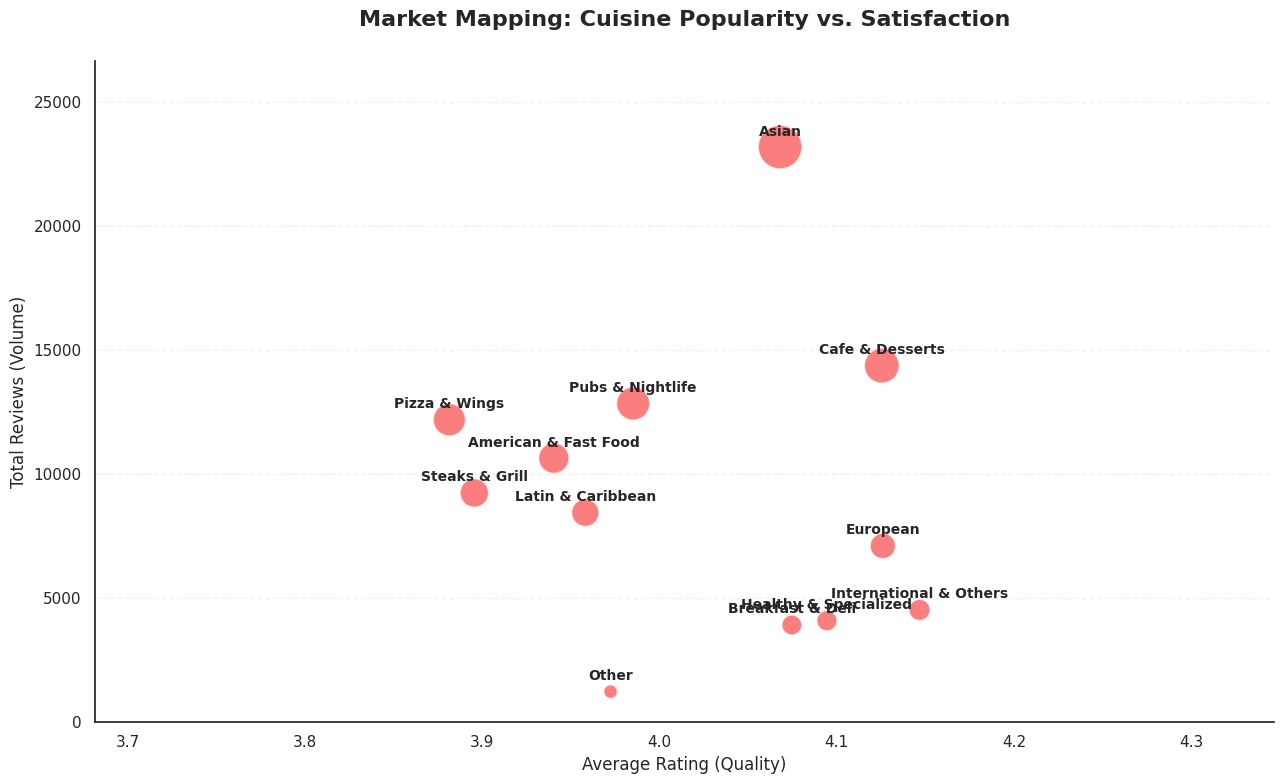

In [ ]:

cuisine_stats = df_ph.groupby('main_cuisine')['rating_user'].agg(['mean', 'count']).reset_index()

plt.figure(figsize=(13, 8))
sns.set_theme(style="white")

sns.scatterplot(
    data=cuisine_stats,
    x='mean',
    y='count',
    size='count',
    sizes=(100, 1000),
    color='#FA4848',
    alpha=0.7,
    legend=False
)

for i in range(cuisine_stats.shape[0]):
    plt.text(
        x=cuisine_stats['mean'][i],
        y=cuisine_stats['count'][i] + (cuisine_stats['count'].max() * 0.02),
        s=cuisine_stats['main_cuisine'][i],
        fontsize=10,
        ha='center',
        fontweight='semibold'
    )


plt.title('Market Mapping: Cuisine Popularity vs. Satisfaction', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Average Rating (Quality)', fontsize=12)
plt.ylabel('Total Reviews (Volume)', fontsize=12)

plt.xlim(cuisine_stats['mean'].min() - 0.2, cuisine_stats['mean'].max() + 0.2)
plt.ylim(0, cuisine_stats['count'].max() * 1.15)

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

Asian and Cafe & Desserts, manage to maintain a strong balance between popularity and quality, with average ratings exceeding 4.07. However, Pizza & Wings and American & Fast Food, having substantial review volumes (between 10,000 and 13,000 reviews), record significantly lower average ratings, hovering around 3.88 to 3.94.

## **Validation metrics function**

In [ ]:
def precision_recall(model, k = 10, threshold = 3.5):
    """Return precision and recall at k metrics for each user"""

    # First map the predictions to each user
    user_est_true = defaultdict(list)

    # Making predictions on the test data
    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key = lambda x: x[0], reverse = True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. Therefore, we are setting Precision to 0 when n_rec_k is 0

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. Therefore, we are setting Recall to 0 when n_rel is 0

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    # Mean of all the predicted precisions are calculated.
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)

    # Mean of all the predicted recalls are calculated.
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)

    rmse_val = accuracy.rmse(predictions, verbose=False)

    # F-1 Score calculation
    if (precision + recall) == 0:
        f1_score = 0
    else:
        f1_score = round((2 * precision * recall) / (precision + recall), 3)

    print('RMSE: ', rmse_val)
    print('Precision: ', precision) # Command to print the overall precision
    print('Recall: ', recall) # Command to print the overall recall
    print('F_1 score: ', f1_score) # Formula to compute the F-1 score

    return rmse_val, precision, recall, f1_score

## **Models**

### **Model 1: Rank Based Recommendation System (baseline)**

Rank-based recommendation system provides recommendations based on the most popular restaurants. This recommendation system is useful when we have cold start problems. When we have new users in the platform and we know nothing about them, we can use a rank-based recommendation system to recommend a restaurant.

In [ ]:
# Calculate the average rating for each product
# Calculate the count of ratings for each product
# Create a dataframe with calculated average and count of ratings
# Sort the dataframe by average of ratings in the descending order
# See the first five records of the "final_rating" dataset

average_rating = df_ph.groupby('business_id')['rating_user'].mean()

count_rating = df_ph.groupby('business_id')['rating_user'].count()
final_rating = pd.DataFrame({'avg_rating':average_rating, 'rating_count':count_rating})
final_rating.sort_values(by = 'avg_rating', ascending = False, inplace = True)
final_rating.head(5)

,avg_rating,rating_count
business_id,,
22471,5.0,4
22812,5.0,2
4273,5.0,3
22998,5.0,1
23043,5.0,2


In [ ]:
def top_n_business(data, n, min_interaction):
    """
    Function to find top n business based on user ratings

    """
    recommendations = data[data['rating_count'] > min_interaction]

    recommendations = recommendations.sort_values(by='avg_rating', ascending=False)

    return recommendations.index[:n]

In [ ]:
# Top 10 recommended restaurants id based on more than 55 interactions
recommended_business_ids = top_n_business(final_rating, 10, 55)

business_info = df_ph.groupby('business_id').agg(
    business_name=('business_name', 'first'),
    review_count=('review_id', 'count')
).reset_index()

recommended_businesses_details = final_rating.loc[recommended_business_ids].reset_index()
results = recommended_businesses_details.merge(business_info, on='business_id', how='left')

print(results[['business_name', 'avg_rating', 'review_count']])

                   business_name  avg_rating  review_count
0  Uncle Bobbie's Coffee & Books    4.760000            75
1              Circles + Squares    4.701754            57
2                   Hikari Sushi    4.666667            72
3                   Vetri Cucina    4.666667            96
4                      Mi 'N Tea    4.640625            64
5                     Mike's BBQ    4.638158           152
6                       Fiorella    4.621951            82
7                         Pho 75    4.620253           158
8                        Burrata    4.617978            89
9           The Bakeshop on 20th    4.614754           122


## Data selection for our model

In [ ]:
df_ph.columns.to_list()

['review_id',
 'business_id',
 'user_id',
 'city',
 'rating_user',
 'review_text',
 'review_date',
 'review_impact_score',
 'index_impact_review',
 'review_quality',
 'business_name',
 'latitude',
 'longitude',
 'user_name',
 'id_friends',
 'main_cuisine',
 'influence_user_index',
 'user_type',
 'ByAppointmentOnly',
 'BusinessAcceptsCreditCards',
 'BikeParking',
 'RestaurantsPriceRange2',
 'RestaurantsTakeOut',
 'RestaurantsDelivery',
 'WiFi',
 'WheelchairAccessible',
 'HappyHour',
 'OutdoorSeating',
 'HasTV',
 'RestaurantsReservations',
 'DogsAllowed',
 'Alcohol',
 'GoodForKids',
 'RestaurantsTableService',
 'RestaurantsGoodForGroups',
 'DriveThru',
 'Smoking',
 'BestNight_Weekend',
 'count_friends']

In [ ]:
df_ph = df_ph[['review_id',
              'business_id',
              'user_id',
              'rating_user',
              'review_text',
              'business_name',
              'id_friends',
              'count_friends']]

In [ ]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_ph[['user_id', 'business_name', 'rating_user']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

In [ ]:
#Select only one example
prueba = testset[0]
prueba

(16337, 'The Taste of Brazil - Philadelphia', 3.0)

### **Model 2: Collaborative Filtering Recommendation System**

### **Building a baseline user-user similarity based recommendation system**

This model generates recommendations by identifying users with similar rating patterns. Since it focuses purely on user behavior rather than restaurant metadata, it is an excellent tool for discovering new experiences that may fall outside a user’s typical categories.

In [ ]:
sim_options = {'name': 'cosine',
               'user_based': True}

sim_user_user = KNNBasic(sim_options=sim_options,verbose=False)

sim_user_user.fit(trainset)

# Validation metrics
precision_recall(sim_user_user)

RMSE:  1.1409554389026226
Precision:  0.73
Recall:  0.793
F_1 score:  0.76


(1.1409554389026226, 0.73, 0.793, 0.76)


- RMSE: Avg. deviation between the predicted rating and the actual rating. On a standard 1–5 star scale, an error of 1.14 is relatively high.

- Precision: proportion of recommended items that are actually relevant to the user. 73% of the items the model suggested were liked by the users. The model is fairly good at avoiding recommending things the user hates.

- Recall: proportion of relevant items that the model successfully found and recommended. The model is capturing nearly 80% of the items a user would potentially like.

- F1 Score: healthy balance between the model's accuracy (Precision) and its coverage (Recall).

In [ ]:
pred = sim_user_user.predict(16337, 'The Taste of Brazil - Philadelphia', r_ui=3.0)
print(pred)

user: 16337      item: The Taste of Brazil - Philadelphia r_ui = 3.00   est = 3.83   {'actual_k': 6, 'was_impossible': False}


In [ ]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {'k': [20, 30, 40], 'min_k': [3, 6, 9],
              'sim_options': {'name': ['msd', 'cosine'],
                              'user_based': [True]}
              }

gs = GridSearchCV(KNNBasic, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

gs.fit(data)
print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

1.1152603562533159
{'k': 40, 'min_k': 6, 'sim_options': {'name': 'msd', 'user_based': True}}


In [ ]:
sim_options = {'name': 'msd',
               'user_based': True}

sim_user_user = KNNBasic(sim_options=sim_options, k=40, min_k=6, verbose=False)

sim_user_user.fit(trainset)

precision_recall(sim_user_user)

RMSE:  1.1203385083796518
Precision:  0.736
Recall:  0.823
F_1 score:  0.777


(1.1203385083796518, 0.736, 0.823, 0.777)

In [ ]:
rmse, prec, rec, f1 = precision_recall(sim_user_user)
df_metrics = pd.DataFrame(columns=['Model', 'RMSE', 'Precision', 'Recall', 'F1-Score', 'Hyperparameters'])

user_user_results = {
    'Model': 'CF User-User',
    'RMSE': round(rmse, 4),
    'Precision': round(prec, 4),
    'Recall': round(rec, 4),
    'F1-Score': round(f1, 4),
    'Hyperparameters': 'k = 40, min_k = 6, msd distance'
}

df_metrics = pd.concat([df_metrics, pd.DataFrame([user_user_results])], ignore_index=True)
display(df_metrics)

RMSE:  1.1203385083796518
Precision:  0.736
Recall:  0.823
F_1 score:  0.777


,Model,RMSE,Precision,Recall,F1-Score,Hyperparameters
0,CF User-User,1.1203,0.736,0.823,0.777,"k = 40, min_k = 6, msd distance"


Through hyperparameter tuning, we achieved a lower RMSE; however, there is still a high variance in rating predictions. While precision remains stable, the proportion of relevant items has improved.


In [ ]:
pred = sim_user_user.predict(16337, 'The Taste of Brazil - Philadelphia', r_ui=3.0)
print(pred)

user: 16337      item: The Taste of Brazil - Philadelphia r_ui = 3.00   est = 3.84   {'actual_k': 6, 'was_impossible': False}


In [ ]:
def get_top_n_recommendations(model, user_id, n=10):
    all_items = trainset.all_items()
    all_items_raw = [trainset.to_raw_iid(i) for i in all_items]

    user_items = [j for (j, _) in trainset.ur[trainset.to_inner_uid(user_id)]]
    user_items_raw = [trainset.to_raw_iid(i) for i in user_items]

    predictions = []
    for item_id in all_items_raw:
        if item_id not in user_items_raw:
            predictions.append(model.predict(user_id, item_id))

    predictions.sort(key=lambda x: x.est, reverse=True)

    return predictions[:n]

top_10 = get_top_n_recommendations(sim_user_user, 16337, n=10)

print(f"--- Top 10 Recomendaciones para el usuario 16337 ---")
for i, p in enumerate(top_10, 1):
    print(f"{i}. Ítem: {p.iid} | Predicción: {p.est:.2f}")

--- Top 10 Recomendaciones para el usuario 16337 ---
1. Ítem: Prima Pizza Taqueria Mexicana | Predicción: 5.00
2. Ítem: Cedar Point Bar and Kitchen | Predicción: 5.00
3. Ítem: Original Liberty Bell Restaurant | Predicción: 5.00
4. Ítem: Restaurant Ambra | Predicción: 5.00
5. Ítem: Mom Mom's Kitchen and Polish Food Cart | Predicción: 5.00
6. Ítem: Community | Predicción: 5.00
7. Ítem: Schmear It | Predicción: 4.98
8. Ítem: Stina Pizzeria | Predicción: 4.95
9. Ítem: Christie's Deli | Predicción: 4.92
10. Ítem: Dig | Predicción: 4.92


In [ ]:
# Generar predicciones para el set de prueba
predictions = sim_user_user.test(testset)

# Filtrar solo las del usuario 16337
user_16337_preds = [p for p in predictions if p.uid == 16337]

for p in user_16337_preds[:10]: # Ver las primeras 10
    print(f"Restaurante: {p.iid}")
    print(f"  - Rating Real (r_ui): {p.r_ui}")
    print(f"  - Predicción del Modelo (est): {p.est:.2f}")
    print(f"  - Diferencia: {abs(p.r_ui - p.est):.2f}\n")

Restaurante: The Taste of Brazil - Philadelphia
  - Rating Real (r_ui): 3.0
  - Predicción del Modelo (est): 3.84
  - Diferencia: 0.84

Restaurante: Yiro Yiro
  - Rating Real (r_ui): 2.0
  - Predicción del Modelo (est): 3.93
  - Diferencia: 1.93



### **Item-Item Similarity-based Collaborative Filtering Recommendation System**

In [ ]:
sim_options = {'name': 'cosine',
               'user_based': False}
similarity_optimized_item = KNNBasic(sim_options={'name': 'cosine', 'user_based': False}, random_state = 1, verbose = False)
similarity_optimized_item.fit(trainset)

precision_recall(similarity_optimized_item)

RMSE:  1.162540580067685
Precision:  0.666
Recall:  0.733
F_1 score:  0.698


(1.162540580067685, 0.666, 0.733, 0.698)


- RMSE:  1.16 is higher than the user-user model.

- Precision: proportion of recommended items that are actually relevant is 66%, lower than user-user model.

- Recall: proportion of relevant items that the model successfully found and recommended is also lower than user-user model.

In [ ]:
pred = similarity_optimized_item.predict(16337, 'The Taste of Brazil - Philadelphia', r_ui=3.0)
print(pred)

user: 16337      item: The Taste of Brazil - Philadelphia r_ui = 3.00   est = 3.38   {'actual_k': 5, 'was_impossible': False}


In [ ]:

param_grid = {'k': [20,30,40], 'min_k': [3,6,9],
              'sim_options': {'name': ['msd', 'cosine'],
                              'user_based': [False]}
              }
grid_obj = GridSearchCV(KNNBasic, param_grid, measures=['rmse', 'mae'], cv=3)

grid_obj.fit(data)

print(grid_obj.best_score['rmse'])

print(grid_obj.best_params['rmse'])

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matr

In [ ]:
similarity_optimized_item = KNNBasic(
    sim_options={'name': 'msd', 'user_based': False},
    k=40,
    min_k=6,
    verbose=False
)
similarity_optimized_item.fit(trainset)
precision_recall(similarity_optimized_item)

RMSE:  1.135626323985349
Precision:  0.729
Recall:  0.827
F_1 score:  0.775


(1.135626323985349, 0.729, 0.827, 0.775)

In [ ]:
rmse_item, prec_item, rec_item, f1_item = precision_recall(similarity_optimized_item)

item_item_results = {
    'Model': 'CF Item-Item',
    'RMSE': round(rmse_item, 4),
    'Precision': round(prec_item, 4),
    'Recall': round(rec_item, 4),
    'F1-Score': round(f1_item, 4),
    'Hyperparameters': 'k = 40, min_k = 6, msd distance'
}

df_metrics = pd.concat([df_metrics, pd.DataFrame([item_item_results])], ignore_index=True)

display(df_metrics)

RMSE:  1.135626323985349
Precision:  0.729
Recall:  0.827
F_1 score:  0.775


,Model,RMSE,Precision,Recall,F1-Score,Hyperparameters
0,CF User-User,1.1203,0.736,0.823,0.777,"k = 40, min_k = 6, msd distance"
1,CF Item-Item,1.1356,0.729,0.827,0.775,"k = 40, min_k = 6, msd distance"


By optimizing the hyperparameters, the RMSE decreased from 1.16 to 1.13, resulting in predictions that are closer to the actual values. The model achieved a Precision of 73% (meaning at least 7 out of 10 recommendations are accurate) and a Recall of 82%, demonstrating a high capacity to capture items of interest to the user. While this outperforms the previous item-item approach, the user-user model establishes itself as the most robust option, offering a lower RMSE while maintaining competitive relevance metrics.

In [ ]:
pred = similarity_optimized_item.predict(16337, 'The Taste of Brazil - Philadelphia', r_ui=3.0)
print(pred)

user: 16337      item: The Taste of Brazil - Philadelphia r_ui = 3.00   est = 4.02   {'was_impossible': True, 'reason': 'Not enough neighbors.'}


In [ ]:
def get_top_n_recommendations(model, user_id, n=10):
    all_items = trainset.all_items()
    all_items_raw = [trainset.to_raw_iid(i) for i in all_items]

    user_items = [j for (j, _) in trainset.ur[trainset.to_inner_uid(user_id)]]
    user_items_raw = [trainset.to_raw_iid(i) for i in user_items]

    predictions = []
    for item_id in all_items_raw:
        if item_id not in user_items_raw:
            predictions.append(model.predict(user_id, item_id))

    predictions.sort(key=lambda x: x.est, reverse=True)

    return predictions[:n]

top_10 = get_top_n_recommendations(similarity_optimized_item, 16337, n=10)

print(f"--- Top 10 Recomendaciones para el usuario 16337 ---")
for i, p in enumerate(top_10, 1):
    print(f"{i}. Ítem: {p.iid} | Predicción: {p.est:.2f}")

--- Top 10 Recomendaciones para el usuario 16337 ---
1. Ítem: Anastasi Seafood | Predicción: 4.29
2. Ítem: Sabrina's Café | Predicción: 4.23
3. Ítem: K-POT Korean BBQ & Hot Pot | Predicción: 4.06
4. Ítem: Sarcone’s Bakery | Predicción: 4.04
5. Ítem: Sardi's Pollo A La Brasa | Predicción: 4.03
6. Ítem: North Third | Predicción: 4.02
7. Ítem: Tony Roni's Pizza Roxborough | Predicción: 4.02
8. Ítem: The Bourse Food Hall | Predicción: 4.02
9. Ítem: Ants Pants Café | Predicción: 4.02
10. Ítem: Bonchon Philadelphia | Predicción: 4.02


### **Model 3: Model-Based Collaborative Filtering - Matrix Factorization**

In [ ]:
svd = SVD(random_state = 1)

svd.fit(trainset)

precision_recall(svd)

RMSE:  1.0390759966760719
Precision:  0.732
Recall:  0.794
F_1 score:  0.762


(1.0390759966760719, 0.732, 0.794, 0.762)

An RMSE of 1.04 is lower than that of the collaborative filtering models. This implies that the gap between the estimate and the reality is narrowing. The Precision is 73%, meaning that out of every 10 recommendations made, more than 7 are actually valued by the user. With a Recall of 79%, the model identifies nearly 80% of the restaurants that the user might enjoy.

In [ ]:
pred = svd.predict(16337, 'The Taste of Brazil - Philadelphia', r_ui=3.0)
print(pred)

user: 16337      item: The Taste of Brazil - Philadelphia r_ui = 3.00   est = 4.13   {'was_impossible': False}


In [ ]:
param_grid = {'n_epochs': [10, 20, 30], 'lr_all': [0.001, 0.005, 0.01],
              'reg_all': [0.2, 0.4, 0.6]}


gs = GridSearchCV(SVD, param_grid, measures = ['rmse'], cv = 3, n_jobs = -1)
gs.fit(data)

print(gs.best_score['rmse'])

print(gs.best_params['rmse'])

1.0262194585585263
{'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.2}


In [ ]:
svd_optimized = SVD(n_epochs = 20, lr_all = 0.01, reg_all = 0.2, random_state = 1)

svd_optimized = svd_optimized.fit(trainset)

precision_recall(svd_optimized)

RMSE:  1.0292174174026623
Precision:  0.721
Recall:  0.785
F_1 score:  0.752


(1.0292174174026623, 0.721, 0.785, 0.752)

In [ ]:
rmse_item, prec_item, rec_item, f1_item = precision_recall(svd_optimized)

svd_results = {
    'Model': 'CF: Matrix Factorization - SVD',
    'RMSE': round(rmse_item, 4),
    'Precision': round(prec_item, 4),
    'Recall': round(rec_item, 4),
    'F1-Score': round(f1_item, 4),
    'Hyperparameters': 'n_epochs = 20, r_all = 0.01, reg_all = 0.2'
}

df_metrics = pd.concat([df_metrics, pd.DataFrame([svd_results])], ignore_index=True)

display(df_metrics)

RMSE:  1.0292174174026623
Precision:  0.721
Recall:  0.785
F_1 score:  0.752


,Model,RMSE,Precision,Recall,F1-Score,Hyperparameters
0,CF User-User,1.1203,0.736,0.823,0.777,"k = 40, min_k = 6, msd distance"
1,CF Item-Item,1.1356,0.729,0.827,0.775,"k = 40, min_k = 6, msd distance"
2,CF: Matrix Factorization - SVD,1.0292,0.721,0.785,0.752,"n_epochs = 20, r_all = 0.01, reg_all = 0.2"


By tuning hyperparameters, we successfully achieved a lower RMSE of 1.0292. The Precision (0.721) and Recall (0.785) scores indicate that the proportion of relevant items being recommended is higher compared to the baseline model.

In [ ]:
pred = svd_optimized.predict(16337, 'The Taste of Brazil - Philadelphia', r_ui=3.0)
print(pred)

user: 16337      item: The Taste of Brazil - Philadelphia r_ui = 3.00   est = 3.93   {'was_impossible': False}


In [ ]:
top_10 = get_top_n_recommendations(svd_optimized, 16337, n=10)

print(f"--- Top 10 Recomendaciones para el usuario 16337 ---")
for i, p in enumerate(top_10, 1):
    print(f"{i}. Ítem: {p.iid} | Predicción: {p.est:.2f}")

--- Top 10 Recomendaciones para el usuario 16337 ---
1. Ítem: The Creperie | Predicción: 4.55
2. Ítem: Castellino's | Predicción: 4.48
3. Ítem: Rieker's Prime Meats | Predicción: 4.46
4. Ítem: Palizzi Filippo Social Club | Predicción: 4.46
5. Ítem: So Korean Grill | Predicción: 4.46
6. Ítem: Marchiano's Bakery | Predicción: 4.43
7. Ítem: Elwood | Predicción: 4.43
8. Ítem: Haggerty Deli | Predicción: 4.43
9. Ítem: Taqueria La Herradura | Predicción: 4.43
10. Ítem: Lost Bread Co. | Predicción: 4.42


### **Model 4: Friend's preferences (Social Graphs)**

The core concept of Friends Preferences is to integrate the user's social network into the SVD matrix factorization model. Unlike the standard model that only analyzes user-restaurant interactions, this approach applies social regularization: it assumes that a user's tastes are influenced by their close circle, assigning greater weight to friends' ratings to 'guide' the overall rating prediction. This strategy aims to reduce the RMSE by leveraging social trust to better navigate the long tail of restaurants with sparse data.

In [ ]:
# Convert the variable into list of numbers
df_ph['id_friends'] = df_ph['id_friends'].apply(
    lambda x: [int(i.strip()) for i in str(x).strip('[]').split(',') if i.strip()] if (x and x != 'None' and x != '[]') else []
)


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create the social graph with users and friends
G = nx.Graph()

for _, row in df_ph.iterrows():
    user = row['user_id']
    friends = row['id_friends']

    # For each users_id in the original dataframe, this creates a point with the user id
    G.add_node(user)

    # This draws the connection between friends if both exist in the dataset
    for friend in friends:
        if G.has_node(friend):
            G.add_edge(user, friend)

print(f"Grafo construido con {G.number_of_nodes()} nodos y {G.number_of_edges()} conexiones.")

# Calculate centrality (influence score) for each user
centrality = nx.degree_centrality(G)

# Once we have all the lines draw, we can calculate who is the person with more connections (influencers)
# How? By counting how many lines each point (user_id) has.
# If the dataset has 100 users and "Florencia" has 10 friends (lines or connections) her score is 10/100, it's an indicator of how connected someone is to the total of users.
df_ph['influence_score'] = df_ph['user_id'].map(centrality)

Grafo construido con 8714 nodos y 32917 conexiones.


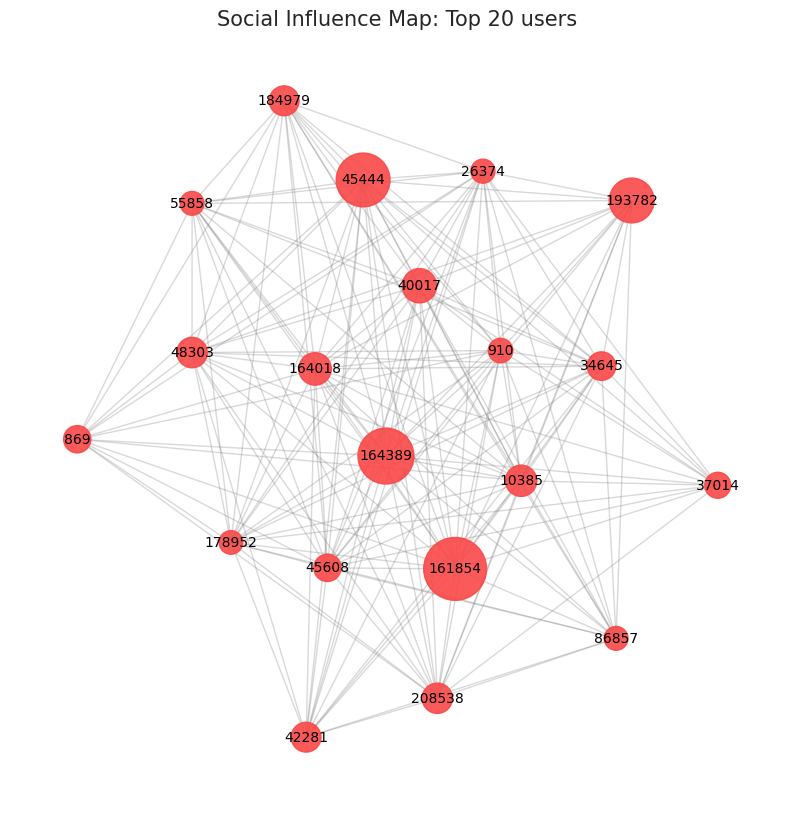

In [ ]:
# Top 20 users with more connections
top_users = sorted(centrality, key=centrality.get, reverse=True)[:20]
subgraph = G.subgraph(top_users)

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(subgraph, seed=42)

labels = {n: n for n in subgraph.nodes()}

# First we draw the nodes
node_size = [centrality[n] * 10000 for n in subgraph.nodes()]
nx.draw_networkx_nodes(
    subgraph,
    pos,
    node_size=node_size,
    node_color="#FA4848",
    alpha=0.9
)

# Draw connections
nx.draw_networkx_edges(subgraph, pos, edge_color="gray", alpha=0.3)

# Labels
nx.draw_networkx_labels(
    subgraph,
    pos,
    labels=labels,
    font_size=10,
    font_color="black"
)

plt.title("Social Influence Map: Top 20 users", fontsize=15)
plt.axis('off')
plt.show()

We know who you trust. We are using this Social Circle as a high-confidence filter to bridge the Trust Gap, ensuring that our top picks aren't just mathematically correct, but socially relevant.

In [ ]:
import math
from surprise import accuracy
from collections import defaultdict

# 1. Diccionario de amigos
dict_amigos = dict(zip(df_ph['user_id'], df_ph['id_friends']))

# 2. Set de búsqueda rápida: (usuario, negocio) con rating >= 4
# Esto es vital para que el conteo de amigos sea rápido
likes_df = df_ph[df_ph['rating_user'] >= 4]
likes_set = set(zip(likes_df['user_id'], likes_df['business_name']))

preds_hibrido = []

for uid, iid, true_r in testset:
    amigos = dict_amigos.get(uid, [])

    # Predicción base del SVD
    pred_obj = svd_optimized.predict(uid, iid, r_ui=true_r)

    # Contamos cuántos amigos recomiendan este negocio específico
    n_amigos_recomiendan = sum(1 for amigo in amigos if (amigo, iid) in likes_set)

    if n_amigos_recomiendan > 0:
        # El bono crece con la cantidad de amigos:
        # 1 amigo ≈ +3.4%, 3 amigos ≈ +6.9%, 10 amigos ≈ +12%
        factor_social = 1 + (0.05 * math.log(n_amigos_recomiendan + 1))
        nota_final = min(pred_obj.est * factor_social, 5.0)
        preds_hibrido.append(pred_obj._replace(est=nota_final))
    else:
        # Si no hay amigos, mantenemos la predicción original
        preds_hibrido.append(pred_obj)

# Predicciones del modelo simple para la comparativa
preds_svd = svd_optimized.test(testset)

def calcular_metricas_pro(predictions, k=10, threshold=3.5):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()

    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return sum(precisions.values()) / len(precisions), sum(recalls.values()) / len(recalls)

# Ejecución de métricas
p_s, r_s = calcular_metricas_pro(preds_svd)
p_h, r_h = calcular_metricas_pro(preds_hibrido)

print("--- RESULTADOS CON BONO PROPORCIONAL (LOG) ---")
print(f"SVD Simple  | Precision: {p_s:.3f} | Recall: {r_s:.3f} | RMSE: {accuracy.rmse(preds_svd, verbose=False):.4f}")
print(f"SVD Híbrido | Precision: {p_h:.3f} | Recall: {r_h:.3f} | RMSE: {accuracy.rmse(preds_hibrido, verbose=False):.4f}")

--- RESULTADOS CON BONO PROPORCIONAL (LOG) ---
SVD Simple  | Precision: 0.721 | Recall: 0.785 | RMSE: 1.0292
SVD Híbrido | Precision: 0.722 | Recall: 0.788 | RMSE: 1.0355


In [ ]:
friends_model = {
    'Model': 'SVD with friends',
    'RMSE': round(1.0355, 4),
    'Precision': round(0.722, 4),
    'Recall': round(0.788, 4),
    'F1-Score': round(0.754, 4),
    'Hyperparameters': 'n_epochs = 20, lr_rate = 0.007, reg = 0.02'
}

df_metrics = pd.concat([df_metrics, pd.DataFrame([friends_model])], ignore_index=True)

display(df_metrics)

,Model,RMSE,Precision,Recall,F1-Score,Hyperparameters
0,CF User-User,1.1203,0.736,0.823,0.777,"k = 40, min_k = 6, msd distance"
1,CF Item-Item,1.1356,0.729,0.827,0.775,"k = 40, min_k = 6, msd distance"
2,CF: Matrix Factorization - SVD,1.0292,0.721,0.785,0.752,"n_epochs = 20, r_all = 0.01, reg_all = 0.2"
3,SVD with friends,1.0355,0.722,0.788,0.754,"n_epochs = 20, lr_rate = 0.007, reg = 0.02"


For this model, we see that the results are almost the same as the simple SVD.

In [ ]:
#Recommendations for only one usesr
user_id_objetivo = 161854
k_recomendaciones = 10

items_usuario = [pred for pred in testset if pred[0] == user_id_objetivo]
reales_dict = {iid: true_r for _, iid, true_r in items_usuario}

recomendaciones_simple = []
recomendaciones_hibrido = []

for uid, iid, true_r in items_usuario:
    pred_simple = svd_optimized.predict(uid, iid, r_ui=true_r)
    recomendaciones_simple.append((iid, pred_simple.est))

    amigos = dict_amigos.get(uid, [])
    n_amigos_recomiendan = sum(1 for amigo in amigos if (amigo, iid) in likes_set)

    if n_amigos_recomiendan > 0:
        factor_social = 1 + (0.05 * math.log(n_amigos_recomiendan + 1))
        nota_hibrida = min(pred_simple.est * factor_social, 5.0)
    else:
        nota_hibrida = pred_simple.est

    recomendaciones_hibrido.append((iid, nota_hibrida))

top_simple = sorted(recomendaciones_simple, key=lambda x: x[1], reverse=True)[:k_recomendaciones]
top_hibrido = sorted(recomendaciones_hibrido, key=lambda x: x[1], reverse=True)[:k_recomendaciones]

n_mostrar = min(len(top_simple), len(top_hibrido))

if n_mostrar > 0:
    df_comparativa = pd.DataFrame({
        'Rank': range(1, n_mostrar + 1),
        'Negocio (SVD)': [item[0] for item in top_simple],
        'Pred. SVD': [round(item[1], 2) for item in top_simple],
        'Rating Real': [reales_dict[item[0]] for item in top_simple],
        'Negocio (Híbrido)': [item[0] for item in top_hibrido],
        'Pred. Hybrid': [round(item[1], 2) for item in top_hibrido],
        'Rating Real (Híb)': [reales_dict[item[0]] for item in top_hibrido]
    })

    print(f"--- Recco analysis: USER {user_id_objetivo} ---")
    print(df_comparativa.to_string(index=False))
else:
    print(f"There are no enough recommendations for the user {user_id_objetivo}")

--- Recco analysis: USER 161854 ---
 Rank                  Negocio (SVD)  Pred. SVD  Rating Real            Negocio (Híbrido)  Pred. Hybrid  Rating Real (Híb)
    1                      Community       4.80          4.0                    Southgate           5.0                5.0
    2             Frangelli's Bakery       4.68          5.0           Vernick Coffee Bar           5.0                4.0
    3                       Stargazy       4.67          5.0                   Alpen Rose           5.0                4.0
    4               Red Poke Express       4.63          3.0                        Tinto           5.0                5.0
    5             Vernick Coffee Bar       4.60          4.0                  A La Mousse           5.0                5.0
    6                 Bloomsday Cafe       4.56          5.0              Bud & Marilyn's           5.0                4.0
    7 Nick's Old Original Roast Beef       4.54          4.0              Pizzeria Stella           5.0

In [ ]:
import pandas as pd

# Definimos una función para que los nombres de los negocios se vean bien (capitalizados)
df_comparativa['Negocio (SVD)'] = df_comparativa['Negocio (SVD)'].str.title()
df_comparativa['Negocio (Híbrido)'] = df_comparativa['Negocio (Híbrido)'].str.title()

# Aplicamos el estilo profesional
styled_df = df_comparativa.style.set_caption(f"Análisis de Recomendaciones: Usuario {user_id_objetivo}") \
    .set_properties(**{'text-align': 'center', 'padding': '10px', 'border': '1px solid #ddd'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-family', 'sans-serif')]},
        {'selector': 'caption', 'props': [('color', '#2c3e50'), ('font-size', '18px'), ('font-weight', 'bold'), ('padding-bottom', '10px')]}
    ]) \
    .background_gradient(subset=['Pred. SVD'], cmap='Blues') \
    .background_gradient(subset=['Pred. Hybrid'], cmap='YlGn') \
    .format({'Pred. SVD': "{:.2f}", 'Pred. Hybrid': "{:.2f}"})

# Mostrar la tabla
styled_df

,Rank,Negocio (SVD),Pred. SVD,Rating Real,Negocio (Híbrido),Pred. Hybrid,Rating Real (Híb)
0,1,Community,4.80,4.000000,Southgate,5.00,5.000000
1,2,Frangelli'S Bakery,4.68,5.000000,Vernick Coffee Bar,5.00,4.000000
2,3,Stargazy,4.67,5.000000,Alpen Rose,5.00,4.000000
3,4,Red Poke Express,4.63,3.000000,Tinto,5.00,5.000000
4,5,Vernick Coffee Bar,4.60,4.000000,A La Mousse,5.00,5.000000
5,6,Bloomsday Cafe,4.56,5.000000,Bud & Marilyn'S,5.00,4.000000
6,7,Nick'S Old Original Roast Beef,4.54,4.000000,Pizzeria Stella,5.00,5.000000
7,8,A La Mousse,4.54,5.000000,Harp & Crown,5.00,5.000000
8,9,A La Mousse,4.54,5.000000,La Calaca Feliz,5.00,5.000000
9,10,Oishii Poké,4.50,5.000000,Ratchada Thai & Laos Cuisine,5.00,4.000000


### **Model 5: Sentiment Analysis - SVD boosting**

In [ ]:
df_ph_text = df_ph.copy()

In [ ]:
# VADER, is a word dictionary that gives the words a positive, negative or neutral connotation.

sia = SentimentIntensityAnalyzer()

# Sentiment Score: from each review, the function extracts the 'compound', it's a metric that summaries the total sentiment in a range from -1 (very negative) to 1 (very positive)
df_ph_text['sentiment_score'] = [sia.polarity_scores(str(x))['compound'] for x in df_ph_text['review_text']]

In [ ]:
# Normalize to compare with 1 to 5 rating
df_ph_text['sentiment_rating'] = (df_ph_text['sentiment_score'] + 1) * 2 + 1

print(df_ph_text[['review_text', 'rating_user', 'sentiment_score', 'sentiment_rating']])

                                               review_text  rating_user  \
4        My boyfriend and I tried this deli for the fir...            5   
7        I've only had the cannolis here but they are a...            5   
32       A wee bit pricey for the portions they serve. ...            4   
35       Went here with a friend after having an incred...            5   
52       Beautiful clean shop with knock your socks off...            4   
...                                                    ...          ...   
1841970  After much deliberation, we decided to try Abe...            5   
1842005  I visited Mei Mei for the first time to celebr...            4   
1842018  The best spot for some dishes I love like cha ...            5   
1842025  I decided to try this place out after Christma...            4   
1842027  When I first heard that the Peace A Pizza (htt...            4   

         sentiment_score  sentiment_rating  
4                 0.9168            4.8336  
7        

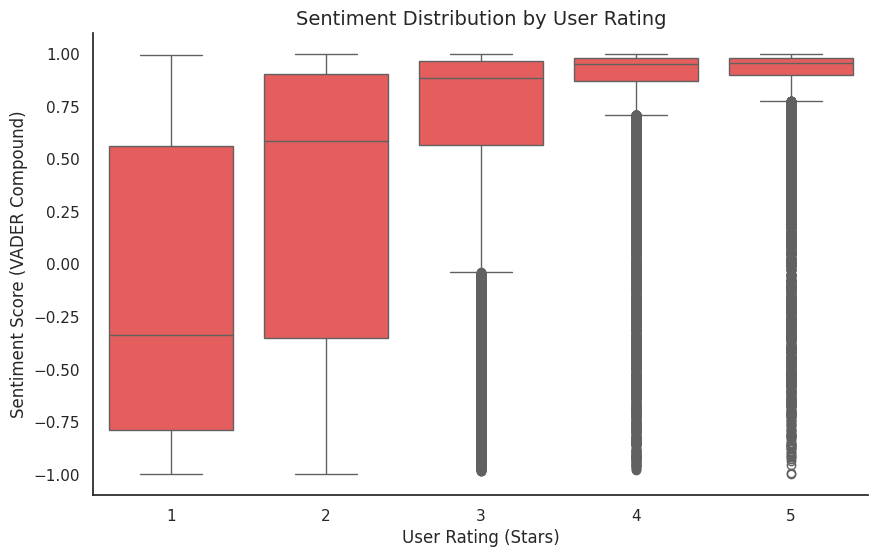

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='rating_user', y='sentiment_score', data=df_ph_text, color='#FA4848')

plt.title('Sentiment Distribution by User Rating', fontsize=14)
plt.xlabel('User Rating (Stars)', fontsize=12)
plt.ylabel('Sentiment Score (VADER Compound)', fontsize=12)
sns.despine()
plt.show()

This chart shows the Sentiment Distribution by User Rating. As you can see, there is a clear positive correlation between the ratings and the sentiment score. When the rating is high, like a 4 or 5, the sentiment is mostly positive, staying close to 1.0. On the other hand, for lower ratings, the sentiment is more spread out and negative. This confirms that the text reviews provide valuable information that the ratings alone might miss, which is why we included sentiment in our SVD model.

In [ ]:
import spacy
# Apply lemmatization to reduce words to their linguistic roots (for example, 'eating' becomes 'eat'). This standardizes the language across all reviews for better analysis.
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

def lemmatize_text(text):
    if not isinstance(text, str):
        return ""
    doc = nlp(text.lower())

    return " ".join([token.lemma_ for token in doc])

# Apply lemmatization
df_ph_text['text_lemmatized'] = df_ph_text['review_text'].apply(lemmatize_text)

# Run VADER over lemmatized text
df_ph_text['sentiment_score_lemma'] = [sia.polarity_scores(x)['compound'] for x in df_ph_text['text_lemmatized']]
df_ph_text['sentiment_rating_lemma'] = (df_ph_text['sentiment_score_lemma'] + 1) * 2 + 1


In [ ]:
df_ph_text[['review_text', 'rating_user', 'sentiment_score', 'sentiment_rating', 'sentiment_score_lemma', 'sentiment_rating_lemma']]

,review_text,rating_user,sentiment_score,sentiment_rating,sentiment_score_lemma,sentiment_rating_lemma
4,My boyfriend and I tried this deli for the fir...,5,0.9168,4.8336,0.9060,4.8120
7,I've only had the cannolis here but they are a...,5,0.9629,4.9258,0.9629,4.9258
32,A wee bit pricey for the portions they serve. ...,4,0.7754,4.5508,0.7754,4.5508
35,Went here with a friend after having an incred...,5,0.9933,4.9866,0.9903,4.9806
52,Beautiful clean shop with knock your socks off...,4,0.9854,4.9708,0.9847,4.9694
...,...,...,...,...,...,...
1841970,"After much deliberation, we decided to try Abe...",5,0.9803,4.9606,0.9793,4.9586
1842005,I visited Mei Mei for the first time to celebr...,4,0.9983,4.9966,0.9983,4.9966
1842018,The best spot for some dishes I love like cha ...,5,0.7506,4.5012,0.7783,4.5566
1842025,I decided to try this place out after Christma...,4,0.9799,4.9598,0.9826,4.9652


In [ ]:
#Define weights for rating_user and sentiment_rating
w1 = 0.8  # user_rating
w2 = 0.2  # sentiment_rating

# Add Rating_final
df_ph_text['rating_final'] = (w1 * df_ph_text['rating_user']) + (w2 * df_ph_text['sentiment_rating'])

print(df_ph_text[['review_text', 'rating_user', 'sentiment_rating', 'rating_final']].head())

                                          review_text  rating_user  \
4   My boyfriend and I tried this deli for the fir...            5   
7   I've only had the cannolis here but they are a...            5   
32  A wee bit pricey for the portions they serve. ...            4   
35  Went here with a friend after having an incred...            5   
52  Beautiful clean shop with knock your socks off...            4   

    sentiment_rating  rating_final  
4             4.8336       4.96672  
7             4.9258       4.98516  
32            4.5508       4.11016  
35            4.9866       4.99732  
52            4.9708       4.19416  


In [ ]:
data_final = Dataset.load_from_df(df_ph_text[['user_id', 'business_id', 'rating_final']], reader)

trainset_final, testset_final = train_test_split(data_final, test_size=0.2, random_state=42)

#Train new model
svd_text = SVD(random_state=1)
svd_text.fit(trainset_final)

predictions = svd_text.test(testset_final)
precision_recall(svd_text)

RMSE:  1.110254046078213
Precision:  0.728
Recall:  0.846
F_1 score:  0.783


(1.110254046078213, 0.728, 0.846, 0.783)

We achieved a Recall of 0.846, which is a great result because it means the model is successfully identifying the majority of restaurants the user would actually like. The Precision is 0.728, showing a solid balance in our recommendations. Finally, the RMSE is 1.11. While there is always room for improvement, this level of error is perfectly acceptable for our goal, which is discovery and relevance rather than exact rating prediction.

In [ ]:
pred = svd_text.predict(16337, 'The Taste of Brazil - Philadelphia', r_ui=3.0)
print(pred)

user: 16337      item: The Taste of Brazil - Philadelphia r_ui = 3.00   est = 3.89   {'was_impossible': False}


In [ ]:

user_id_test = 161854
k_recomendaciones = 10

mapa_nombres = dict(zip(df_ph_text['business_id'], df_ph_text['business_name']))

todos_los_items = df_ph_text['business_id'].unique()
items_visitados = df_ph_text[df_ph_text['user_id'] == user_id_test]['business_id'].tolist()

items_por_predecir = [item for item in todos_los_items if item not in items_visitados]


predicciones_nuevas = []
for item_id in items_por_predecir:
    pred = svd_text.predict(user_id_test, item_id)
    predicciones_nuevas.append(pred)


predicciones_nuevas.sort(key=lambda x: x.est, reverse=True)
top_10_final = predicciones_nuevas[:k_recomendaciones]


df_portafolio = pd.DataFrame([
    {
        'Rank': i + 1,
        'Restaurante': mapa_nombres.get(p.iid, p.iid),
        'Score Predicho': round(p.est, 2),
        'Confianza': "Alta" if p.est > 4 else "Media"
    } for i, p in enumerate(top_10_final)
])

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #d4edda' if v else '' for v in is_max]

styled_final = df_portafolio.style.background_gradient(subset=['Score Predicho'], cmap='YlGn') \
    .set_caption(f"Motor de Recomendación: Sugerencias de Descubrimiento para Usuario {user_id_test}") \
    .set_properties(**{'text-align': 'left', 'padding': '10px'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white')]}
    ]) \
    .hide(axis='index')

# --- 5. SALIDA ---
print(f"Generando Top {k_recomendaciones} recomendaciones personalizadas...")
styled_final

Generando Top 10 recomendaciones personalizadas...


Rank,Restaurante,Score Predicho,Confianza
1,Marinucci's Deli - Mayfair,5.000000,Alta
2,Restaurant Ambra,5.000000,Alta
3,Sampan,5.000000,Alta
4,Circles + Squares,4.990000,Alta
5,Daleng Restaurant,4.970000,Alta
6,Ken Love's BYOB,4.970000,Alta
7,Mole Poblano Restaurant,4.960000,Alta
8,Hadramout,4.960000,Alta
9,Lost Bread Co.,4.960000,Alta
10,Vetri Cucina,4.950000,Alta


In [ ]:


user_id_test = 161854

df_visitados = df_ph_text[df_ph_text['user_id'] == user_id_test].copy()

predicciones_historial = []

for index, row in df_visitados.iterrows():
    item_id = row['business_id']
    nota_real = row['rating_final']


    pred = svd_text.predict(user_id_test, item_id)

    predicciones_historial.append({
        'Restaurante': row['business_name'],
        'Rating Real (+Sentimiento)': round(nota_real, 2),
        'Predicción del Modelo': round(pred.est, 2),
        'Diferencia (Error)': round(abs(nota_real - pred.est), 2)
    })


df_analisis_fidelidad = pd.DataFrame(predicciones_historial).sort_values(by='Rating Real (+Sentimiento)', ascending=False)


styled_fidelidad = df_analisis_fidelidad.style.background_gradient(subset=['Diferencia (Error)'], cmap='Reds') \
    .background_gradient(subset=['Predicción del Modelo'], cmap='YlGn') \
    .set_caption(f"Análisis de Fidelidad: Validación sobre locales visitados - Usuario {user_id_test}") \
    .set_properties(**{'text-align': 'left', 'padding': '10px'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white')]}
    ]) \
    .hide(axis='index')


styled_fidelidad

Restaurante,Rating Real (+Sentimiento),Predicción del Modelo,Diferencia (Error)
Friday Saturday Sunday,5.000000,4.840000,0.160000
Morimoto,5.000000,4.670000,0.320000
Irwin's,5.000000,4.570000,0.430000
Pizzeria Beddia,5.000000,4.620000,0.370000
Small Oven Pastry Shop,5.000000,4.600000,0.390000
Pizzeria Stella,5.000000,4.420000,0.580000
Square Pie,5.000000,4.810000,0.190000
Bud & Marilyn's,5.000000,4.490000,0.510000
Oishii Poké,5.000000,4.570000,0.420000
Cafe Lift,5.000000,4.660000,0.340000


In [ ]:
rmse_item, prec_item, rec_item, f1_item = precision_recall(svd_text)

item_item_results = {
    'Model': 'SVD with sentiment',
    'RMSE': round(rmse_item, 4),
    'Precision': round(prec_item, 4),
    'Recall': round(rec_item, 4),
    'F1-Score': round(f1_item, 4),
    'Hyperparameters': 'n_epochs = 20, lr_rate = 0.007, reg = 0.02'
}

df_metrics = pd.concat([df_metrics, pd.DataFrame([item_item_results])], ignore_index=True)

display(df_metrics)

RMSE:  1.110254046078213
Precision:  0.728
Recall:  0.846
F_1 score:  0.783


,Model,RMSE,Precision,Recall,F1-Score,Hyperparameters
0,CF User-User,1.1203,0.736,0.823,0.777,"k = 40, min_k = 6, msd distance"
1,CF Item-Item,1.1356,0.729,0.827,0.775,"k = 40, min_k = 6, msd distance"
2,CF: Matrix Factorization - SVD,1.0292,0.721,0.785,0.752,"n_epochs = 20, r_all = 0.01, reg_all = 0.2"
3,SVD with friends,1.0355,0.722,0.788,0.754,"n_epochs = 20, lr_rate = 0.007, reg = 0.02"
4,SVD with sentiment,1.1103,0.728,0.846,0.783,"n_epochs = 20, lr_rate = 0.007, reg = 0.02"
5,SVD with sentiment,1.1103,0.728,0.846,0.783,"n_epochs = 20, lr_rate = 0.007, reg = 0.02"


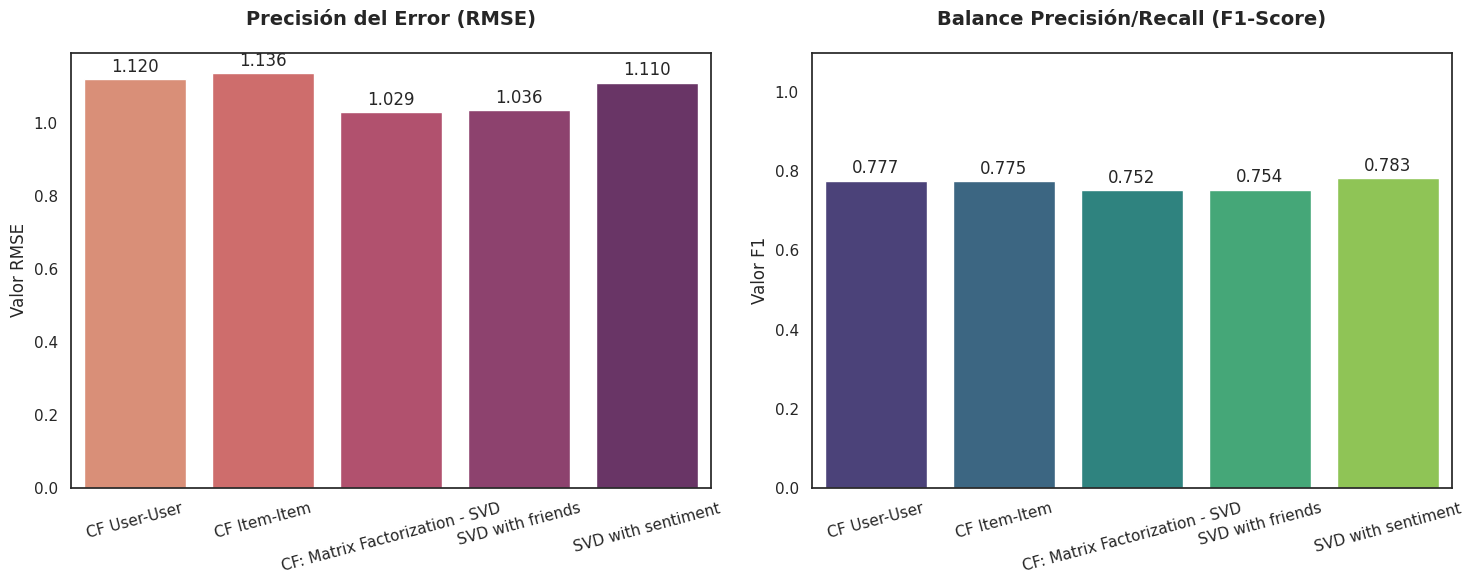

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo
sns.set_style("white")
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 2. Gráfico de RMSE (Error - ¡Menor es mejor!)
# Usamos un color rojo/naranja para indicar "error"
sns.barplot(x='Model', y='RMSE', data=df_metrics, ax=ax[0], palette='flare')
ax[0].set_title('Precisión del Error (RMSE)', fontsize=14, fontweight='bold', pad=20)
ax[0].set_ylabel('Valor RMSE')
ax[0].set_xlabel('')
ax[0].tick_params(axis='x', rotation=15)

# Añadir etiquetas de valor sobre las barras
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# 3. Gráfico de F1-Score o Recall (Efectividad - ¡Mayor es mejor!)
# Usamos un color verde/azul para indicar "éxito"
sns.barplot(x='Model', y='F1-Score', data=df_metrics, ax=ax[1], palette='viridis')
ax[1].set_title('Balance Precisión/Recall (F1-Score)', fontsize=14, fontweight='bold', pad=20)
ax[1].set_ylabel('Valor F1')
ax[1].set_xlabel('')
ax[1].set_ylim(0, 1.1) # El F1 va de 0 a 1
ax[1].tick_params(axis='x', rotation=15)

# Añadir etiquetas de valor sobre las barras
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

# **Conclusions and recommendations**



Although the RMSE is slightly above 1, our goal is not to predict the exact rating a user would give. Instead, we focus on Recall to determine the best model, as it measures the percentage of relevant restaurants successfully recommended.

In this regard, the best-performing model is SVD with Sentiment Analysis, achieving a Recall of 84%.

**Our Recommendations:**

For new users (Cold Start): Provide recommendations based on the overall average ratings of the restaurants.

For active users: As users interact more with the platform, we suggest using a hybrid approach with different models for specific sections:

Potential Sections:

1. 'Based on your past reviews': Powered by the SVD with Sentiment model.

2. 'What your friends recommend': Powered by the SVD with Friends model.

3. 'Restaurants similar to your history': Powered by the Item-Item Collaborative Filtering (CF) model.

# **Next steps**

We recognize that our models have several limitations. For instance, Item-Item Collaborative Filtering (CF) is unable to suggest restaurants outside of what the user has already visited; additionally, it does not scale well with very large data volumes.

The SVD with Friends model is limited by the number of friends a user has on the app. If a user does not have many friends, the model cannot improve or accurately capture the influence of their social circle on their preferences.

For these reasons, the Next Steps for our project are:

* Integrate Semantic Analysis to process user reviews and refine our model.

* Evaluate model performance by taking the user lifecycle within the application into account.

* Try the model lightfm, to introduce metadata of the restaurant (price range, category, good for groups etc).

* Consolidate the model that integrates the user's friends with sentiment analysis.

* Transition to Neural Collaborative Filtering to capture non-linear relationships between users and items.

* Local Deployment: Developing a mobile application for the Uruguayan market.

